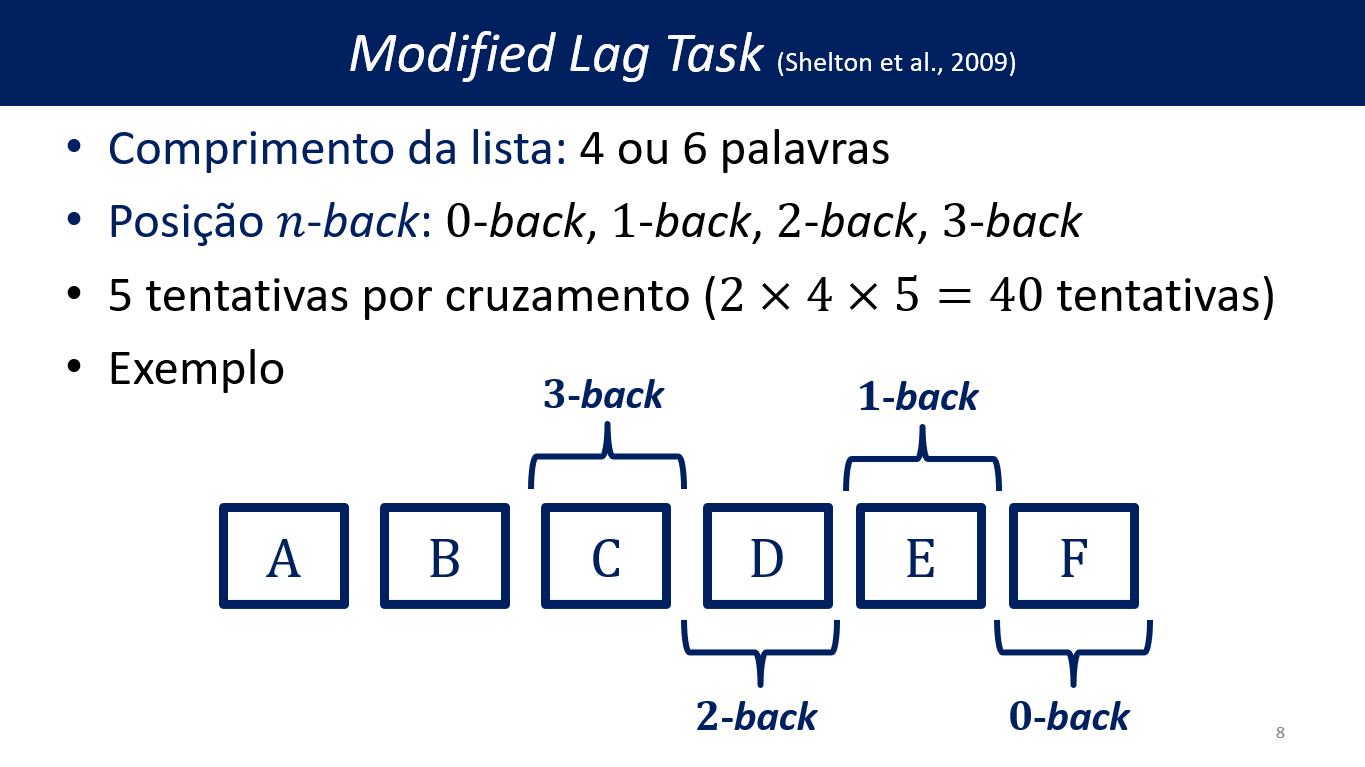

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import FormatStrFormatter

path = "C:/Users/limap/OneDrive/Área de Trabalho/Aula 078 – Color–Shape Task/data/"
df = pd.read_csv(f"{path}826594791_2025-09-20_20h04.34.469_Marcos_css-task.csv", sep = ",")

df.shape

(707, 85)

In [8]:
data = df[['condition', 'phase', 'block', 'cue', 'shape', 'color', 'trial_type',
       'resp_corr', 'resp_2.keys', 'resp_2.corr', 'resp_2.rt', 
       'resp.keys', 'resp.corr', 'resp.rt']
         ]

data.head(10)

,condition,phase,block,cue,shape,color,trial_type,resp_corr,resp_2.keys,resp_2.corr,resp_2.rt,resp.keys,resp.corr,resp.rt
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,homogeneous,color,None,None,triangle,green,None,right,right,1.0,0.585488,NaN,NaN,NaN
2,homogeneous,color,None,None,circle,green,None,right,right,1.0,0.467156,NaN,NaN,NaN
3,homogeneous,color,None,None,triangle,green,None,right,right,1.0,0.367336,NaN,NaN,NaN
4,homogeneous,color,None,None,triangle,blue,None,left,left,1.0,0.387339,NaN,NaN,NaN
5,homogeneous,color,None,None,circle,green,None,right,right,1.0,0.351984,NaN,NaN,NaN
6,homogeneous,color,None,None,circle,blue,None,left,left,1.0,0.302127,NaN,NaN,NaN
7,homogeneous,color,None,None,triangle,blue,None,left,left,1.0,0.334892,NaN,NaN,NaN
8,homogeneous,color,None,None,circle,blue,None,left,left,1.0,0.302396,NaN,NaN,NaN
9,homogeneous,color,None,None,circle,green,None,right,right,1.0,0.369209,NaN,NaN,NaN


In [11]:
# Se a condição é "homogeneous", usamos as colunas resp_2.*
# Se a condição é "heterogeneous", usamos resp.*
# Assim, criamos colunas padronizadas "resp_key", "resp_corr_bin" e "rt"
data["resp_key"] = data.apply(
    lambda row: row["resp_2.keys"] if row["condition"] == "homogeneous" else row["resp.keys"],
    axis = 1
)

# Acurácia binária (1 = acerto, 0 = erro)
data["resp_corr_bin"] = data.apply(
    lambda row: row["resp_2.corr"] if row["condition"] == "homogeneous" else row["resp.corr"],
    axis = 1
)

# Tempo de reação
data["rt"] = data.apply(
    lambda row: row["resp_2.rt"] if row["condition"] == "homogeneous" else row["resp.rt"],
    axis = 1
)

data.head(3)

C:\Users\limap\AppData\Local\Temp\ipykernel_10232\3364590505.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["resp_key"] = data.apply(
C:\Users\limap\AppData\Local\Temp\ipykernel_10232\3364590505.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["resp_corr_bin"] = data.apply(
C:\Users\limap\AppData\Local\Temp\ipykernel_10232\3364590505.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

,condition,phase,block,cue,shape,color,trial_type,resp_corr,resp_2.keys,resp_2.corr,resp_2.rt,resp.keys,resp.corr,resp.rt,resp_key,resp_corr_bin,rt
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,homogeneous,color,None,None,triangle,green,None,right,right,1.0,0.585488,NaN,NaN,NaN,right,1.0,0.585488
2,homogeneous,color,None,None,circle,green,None,right,right,1.0,0.467156,NaN,NaN,NaN,right,1.0,0.467156


In [12]:
# --------------------------------------------------------
# 2. Calcular métricas de interesse (RT médio e erro médio)
# --------------------------------------------------------

# Função auxiliar para erro médio (1 - acurácia média)
def error_rate(x):
    return 1 - x.mean()

# RT e taxa de erro por condição/tipo de trial
summary = data.groupby(["condition", "trial_type"]).agg(
    mean_rt = ("rt", "mean"),
    error_rate = ("resp_corr_bin", error_rate)
).reset_index()

# Também precisamos das médias colapsadas por condição (sem trial_type)
summary_global = data.groupby(["condition"]).agg(
    mean_rt = ("rt", "mean"),
    error_rate = ("resp_corr_bin", error_rate)
).reset_index()

In [13]:
# --------------------------------------------------------
# 3. Calcular custos
# --------------------------------------------------------

# --- Switch Cost (heterogeneous only) ---
# Diferença entre switch e no-switch dentro da condição heterogeneous
hetero = summary[summary["condition"] == "heterogeneous"].set_index("trial_type")

switch_rt_cost = hetero.loc["switch", "mean_rt"] - hetero.loc["no-switch", "mean_rt"]
switch_acc_cost = hetero.loc["switch", "error_rate"] - hetero.loc["no-switch", "error_rate"]

# --- Mixing Cost ---
# Diferença entre no-switch trials em heterogeneous e trials de homogeneous
homo = summary_global[summary_global["condition"] == "homogeneous"]
hetero_noswitch = hetero.loc["no-switch"]

mixing_rt_cost = hetero_noswitch["mean_rt"] - homo["mean_rt"].values[0]
mixing_acc_cost = hetero_noswitch["error_rate"] - homo["error_rate"].values[0]

# --- Global Cost ---
# Diferença entre médias gerais de heterogeneous e homogeneous
hetero_global = summary_global[summary_global["condition"] == "heterogeneous"]

global_rt_cost = hetero_global["mean_rt"].values[0] - homo["mean_rt"].values[0]
global_acc_cost = hetero_global["error_rate"].values[0] - homo["error_rate"].values[0]

# --------------------------------------------------------
# 4. Mostrar resultados
# --------------------------------------------------------

print("=== SWITCH COST (heterogeneous only) ===")
print(f"RT: {switch_rt_cost:.4f} (switch - no-switch)")
print(f"ACC: {switch_acc_cost:.4f} (error rate switch - no-switch)")

print("\n=== MIXING COST ===")
print(f"RT: {mixing_rt_cost:.4f} (no-switch hetero - homogeneous)")
print(f"ACC: {mixing_acc_cost:.4f} (error rate no-switch hetero - homogeneous)")

print("\n=== GLOBAL COST ===")
print(f"RT: {global_rt_cost:.4f} (hetero - homo)")
print(f"ACC: {global_acc_cost:.4f} (error rate hetero - homo)")


=== SWITCH COST (heterogeneous only) ===
RT: 0.1321 (switch - no-switch)
ACC: 0.0160 (error rate switch - no-switch)

=== MIXING COST ===
RT: 0.5995 (no-switch hetero - homogeneous)
ACC: 0.0220 (error rate no-switch hetero - homogeneous)

=== GLOBAL COST ===
RT: 0.6656 (hetero - homo)
ACC: 0.0300 (error rate hetero - homo)


In [35]:
# Simular summary_global e summary com valores consistentes aos exemplos anteriores
# (na prática, seriam os resultados do código do usuário com o CSV real)
summary = pd.DataFrame({
    "condition": ["heterogeneous","heterogeneous"],
    "trial_type": ["no-switch","switch"],
    "mean_rt": [1.45, 1.58],  # segundos
    "error_rate": [0.12, 0.136]  # proporção de erros
})
summary_global = pd.DataFrame({
    "condition": ["homogeneous","heterogeneous"],
    "mean_rt": [0.85, 1.515],
    "error_rate": [0.10, 0.13]
})

# Extrair valores reais
homo_rt = summary_global.loc[summary_global["condition"]=="homogeneous","mean_rt"].values[0]
homo_err = summary_global.loc[summary_global["condition"]=="homogeneous","error_rate"].values[0]

hetero_rt = summary_global.loc[summary_global["condition"]=="heterogeneous","mean_rt"].values[0]
hetero_err = summary_global.loc[summary_global["condition"]=="heterogeneous","error_rate"].values[0]

hetero_noswitch_rt = summary.loc[summary["trial_type"]=="no-switch","mean_rt"].values[0]
hetero_noswitch_err = summary.loc[summary["trial_type"]=="no-switch","error_rate"].values[0]

hetero_switch_rt = summary.loc[summary["trial_type"]=="switch","mean_rt"].values[0]
hetero_switch_err = summary.loc[summary["trial_type"]=="switch","error_rate"].values[0]

# Custos (como antes)
switch_rt_cost = (hetero_switch_rt - hetero_noswitch_rt) * 1000  # em ms
switch_acc_cost = (hetero_switch_err - hetero_noswitch_err) * 100  # em %

mixing_rt_cost = (hetero_noswitch_rt - homo_rt) * 1000
mixing_acc_cost = (hetero_noswitch_err - homo_err) * 100

global_rt_cost = (hetero_rt - homo_rt) * 1000
global_acc_cost = (hetero_err - homo_err) * 100

# Preparar dados para plot
rt_costs = [switch_rt_cost, mixing_rt_cost, global_rt_cost]
acc_costs = [switch_acc_cost, mixing_acc_cost, global_acc_cost]
labels = ["Switch", "Mixing", "Global"]

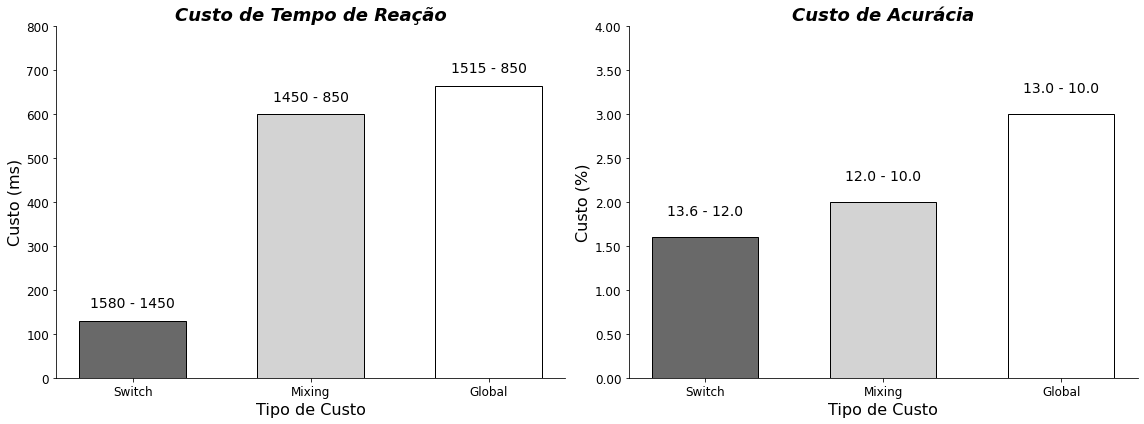

In [39]:
# Criar figura com 2 painéis
fig, axes = plt.subplots(1,2, figsize=(16,6))

# --- Painel 1: RTs ---
axes[0].bar(labels, rt_costs, width=0.6,
            color=["dimgray", "lightgray", "white"], edgecolor="black")
axes[0].set_ylabel("Custo (ms)", fontsize=16)
axes[0].set_xlabel("Tipo de Custo", fontsize=16)
axes[0].set_title("Custo de Tempo de Reação", fontsize=18, fontweight="bold", fontstyle="italic")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_ylim(0, 800)
axes[0].tick_params(labelsize = 12)

# Anotar valores individuais que deram origem às diferenças
# Switch cost -> diferença entre hetero switch e hetero no-switch
axes[0].annotate(f"{hetero_switch_rt*1000:.0f} - {hetero_noswitch_rt*1000:.0f}",
                 xy=(0, rt_costs[0]), xytext=(0, rt_costs[0]+30),
                 ha="center", fontsize = 14)
# Mixing cost -> hetero no-switch - homo
axes[0].annotate(f"{hetero_noswitch_rt*1000:.0f} - {homo_rt*1000:.0f}",
                 xy=(1, rt_costs[1]), xytext=(1, rt_costs[1]+30),
                 ha="center", fontsize = 14)
# Global cost -> hetero - homo
axes[0].annotate(f"{hetero_rt*1000:.0f} - {homo_rt*1000:.0f}",
                 xy=(2, rt_costs[2]), xytext=(2, rt_costs[2]+30),
                 ha="center", fontsize = 14)

# --- Painel 2: ACC ---
axes[1].bar(labels, acc_costs, width=0.6,
            color=["dimgray", "lightgray", "white"], edgecolor="black")
axes[1].set_ylabel("Custo (%)", fontsize=16)
axes[1].set_xlabel("Tipo de Custo", fontsize=16)
axes[1].set_title("Custo de Acurácia", fontsize=18, fontweight="bold", fontstyle="italic")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_ylim(0, 4)
axes[1].tick_params(labelsize = 12)

# duas casas decimais no eixo y do segundo painel
axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

# Anotar valores individuais
axes[1].annotate(f"{hetero_switch_err*100:.1f} - {hetero_noswitch_err*100:.1f}",
                 xy=(0, acc_costs[0]), xytext=(0, acc_costs[0]+0.25),
                 ha="center", fontsize = 14)
axes[1].annotate(f"{hetero_noswitch_err*100:.1f} - {homo_err*100:.1f}",
                 xy=(1, acc_costs[1]), xytext=(1, acc_costs[1]+0.25),
                 ha="center", fontsize = 14)
axes[1].annotate(f"{hetero_err*100:.1f} - {homo_err*100:.1f}",
                 xy=(2, acc_costs[2]), xytext=(2, acc_costs[2]+0.25),
                 ha="center", fontsize = 14)

plt.tight_layout()

plt.savefig("color-shape-switching-task.jpg", dpi = 600, bbox_inches = "tight")

plt.show()
